<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial08B/Tutorial08B_Object_Detection_Pre_Trained_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1: Environment Setup & Model Loading**

In [ ]:
# Import PyTorch and Torchvision
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

# 1. Setup Device (Use GPU if available)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# 2. Download and Load the Pre-Trained Model
# We use the DEFAULT weights, which are the best available weights trained on the COCO dataset
print("Downloading pre-trained Faster R-CNN model...")
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# Move the model to the GPU and set it to Evaluation Mode
model.to(device)
model.eval()
print("Model successfully loaded and set to .eval() mode!")

# 3. Define the COCO Class Names
# The model outputs a number (e.g., 17). This list translates that number into a human-readable word (e.g., 'cat').
# Note: Some indices are empty ('N/A') due to how the original dataset was indexed.
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

print(f"Loaded {len(COCO_INSTANCE_CATEGORY_NAMES)} COCO categories.")

Using device: cpu
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 152MB/s]


Model successfully loaded and set to .eval() mode!
Loaded 91 COCO categories.


# **2: Image Preparation & Inference**

In [ ]:
# Import PIL for image loading and torchvision transforms
from PIL import Image
import torchvision.transforms.functional as F
import torch

# 1. Load the Image
# Make sure the filename matches what you uploaded to Colab!
image_path = 'street scene.jpeg'
try:
    img = Image.open(image_path).convert("RGB")
    print(f"Successfully loaded '{image_path}'")
except FileNotFoundError:
    print(f"Error: Could not find '{image_path}'. Please check the filename and try again.")

# 2. Transform the Image into a Tensor
# Models only read numbers between 0 and 1. This converts the image into a 3D PyTorch Tensor [Channels, Height, Width]
img_tensor = F.to_tensor(img)

# Models expect a "batch" of images, even if it's just one.
# unsqueeze(0) adds a dummy batch dimension: [Batch, Channels, Height, Width]
img_tensor = img_tensor.unsqueeze(0).to(device)
print(f"Image converted to Tensor with shape: {img_tensor.shape}")

# 3. Pass through the Model (Inference)
print("Passing image through Faster R-CNN...")

# torch.no_grad() tells PyTorch NOT to track gradients.
# This saves memory and makes it run much faster since we are just testing, not training.
with torch.no_grad():
    predictions = model(img_tensor)

# 4. Extract the Raw Data
# The model returns a list of dictionaries (one for each image in the batch). We only have one image, so we grab index [0].
pred = predictions[0]

boxes = pred['boxes']   # The [xmin, ymin, xmax, ymax] coordinates
labels = pred['labels'] # The COCO class index (e.g., 3 for 'car')
scores = pred['scores'] # The confidence percentage (0.0 to 1.0)

print(f"The model found {len(boxes)} potential objects (including low-confidence guesses).")
print("Ready for Step 3 to filter and draw them!")

Successfully loaded 'street scene.jpeg'
Image converted to Tensor with shape: torch.Size([1, 3, 600, 900])
Passing image through Faster R-CNN...
The model found 84 potential objects (including low-confidence guesses).
Ready for Step 3 to filter and draw them!


# **3: Post-Processing & Visualization**

Filtered down to 15 highly confident predictions.


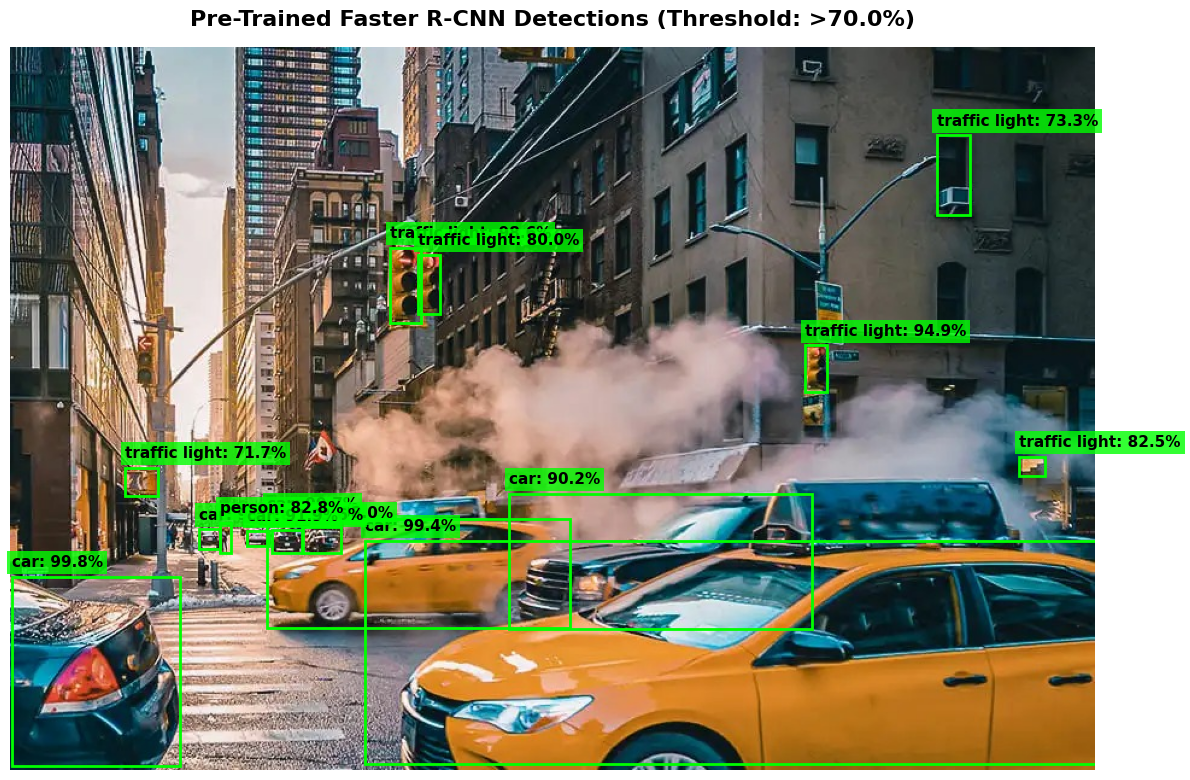

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Set the confidence threshold (Sub-step 3a)
# We only want to see objects the model is at least 70% sure about.
threshold = 0.70
valid_indices = scores >= threshold

# Filter out the low-confidence noise
filtered_boxes = boxes[valid_indices]
filtered_labels = labels[valid_indices]
filtered_scores = scores[valid_indices]

print(f"Filtered down to {len(filtered_boxes)} highly confident predictions.")

# 2. Setup the Matplotlib figure (Sub-step 3b)
fig, ax = plt.subplots(1, figsize=(14, 10))
ax.imshow(img)

# 3. Draw the boxes, names, and scores (Sub-step 3c)
for i, box in enumerate(filtered_boxes):
    # Move tensors back to CPU and convert to numpy for matplotlib
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    width, height = xmax - xmin, ymax - ymin

    # Draw the bounding box (Bright Green)
    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='#00FF00', facecolor='none')
    ax.add_patch(rect)

    # Map the class ID back to the human-readable word
    class_id = filtered_labels[i].item()
    class_name = COCO_INSTANCE_CATEGORY_NAMES[class_id]
    confidence = filtered_scores[i].item() * 100

    # Create the text label
    label_text = f"{class_name}: {confidence:.1f}%"

    # Draw the text with a matching green background for readability
    ax.text(xmin, ymin - 8, label_text, color='black', fontsize=11, weight='bold',
            bbox=dict(facecolor='#00FF00', edgecolor='none', alpha=0.8, pad=3))

# Clean up axes and display the final image
plt.axis('off')
plt.title(f"Pre-Trained Faster R-CNN Detections (Threshold: >{threshold*100}%)", fontsize=16, fontweight='bold', pad=15)
plt.show()

# **4: Evaluation Metrics (IoU & mAP)**

In [ ]:
# CELL 4: Manual IoU Calculation
def calculate_iou(boxA, boxB):
    # 1. Determine the (x, y) coordinates of the intersection rectangle
    # boxes are in [xmin, ymin, xmax, ymax] format
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # 2. Compute the area of intersection
    # We use max(0, ...) to catch cases where the boxes do not overlap at all
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # 3. Compute the area of both the prediction and ground-truth boxes
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # 4. Compute the area of union
    # Union = Area A + Area B - Intersection Area (to avoid double counting)
    unionArea = float(boxAArea + boxBArea - interArea)

    # 5. Calculate IoU
    iou = interArea / unionArea
    return iou

# --- Test the function ---
# Format: [xmin, ymin, xmax, ymax]
ground_truth_box = [50, 50, 150, 150]
predicted_box = [60, 60, 160, 160]

iou_score = calculate_iou(ground_truth_box, predicted_box)
print(f"The IoU between the Ground Truth and Prediction is: {iou_score:.4f}")

The IoU between the Ground Truth and Prediction is: 0.6807


# **5: Understanding AP and mAP Math**

In [ ]:
# CELL 5: Understanding AP and mAP Math
import numpy as np
import matplotlib.pyplot as plt

def calculate_average_precision(predictions, total_ground_truths):
    """
    Calculates AP by finding the area under the Precision-Recall curve.
    """
    # 1. Sort predictions by confidence in descending order
    predictions = sorted(predictions, key=lambda x: x['confidence'], reverse=True)

    TP_cumsum = 0
    FP_cumsum = 0
    precisions = []
    recalls = []

    # 2. Calculate cumulative Precision and Recall at each step
    for pred in predictions:
        if pred['is_true_positive']:
            TP_cumsum += 1
        else:
            FP_cumsum += 1

        precision = TP_cumsum / (TP_cumsum + FP_cumsum)
        recall = TP_cumsum / total_ground_truths

        precisions.append(precision)
        recalls.append(recall)

    # 3. Calculate Area Under the Curve (Average Precision)
    # We add a starting point for the graph (Recall=0, Precision=1)
    recalls = [0.0] + recalls
    precisions = [1.0] + precisions

    # np.trapz does mathematical integration to find the area under the points
    ap = np.trapz(precisions, recalls)
    return ap, precisions, recalls

# --- Test the function with dummy data ---
# Imagine we have 4 actual stop signs in an image.
# The model made 5 predictions. We used IoU to determine if they were right.
total_gt = 4
dummy_predictions = [
    {'confidence': 0.95, 'is_true_positive': True},  # High confidence, correct box
    {'confidence': 0.85, 'is_true_positive': True},  # Good confidence, correct box
    {'confidence': 0.70, 'is_true_positive': False}, # Medium confidence, wrong box (FP)
    {'confidence': 0.60, 'is_true_positive': True},  # Low confidence, correct box
    {'confidence': 0.40, 'is_true_positive': False}  # Very low confidence, wrong box (FP)
]

ap_score, precs, recs = calculate_average_precision(dummy_predictions, total_gt)

print(f"Average Precision (AP) for this class is: {ap_score:.4f}")
print("Because we only have one class (Stop Signs), AP is exactly equal to mAP!")

Average Precision (AP) for this class is: 0.6771
Because we only have one class (Stop Signs), AP is exactly equal to mAP!


/tmp/ipykernel_54376/848114290.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precisions, recalls)
